# EEG Eye State — rigoroso, temporale, con ML + Deep Learning

Questo notebook rifà l'analisi in modo più adatto a un esame:

- **nessuno shuffle**
- **ultimo 30% del dataset come test set untouched**
- **validazione solo nel passato** (`55% train_core`, `15% validation`, `30% test`)
- **windowing causale**: ogni finestra usa solo il passato fino al suo endpoint
- **feature engineering avanzato** per un baseline tabellare forte
- **modelli deep learning moderni** per serie temporali / EEG:
  - **EEGNet-like**
  - **TCN**
  - **InceptionTime-like**
  - **PatchTST-lite** (opzionale, più pesante)
- **threshold tuning e smoothing** fatti **solo sulla validation**
- **ensemble leakage-safe** dei migliori modelli

L'obiettivo qui non è “gonfiare” i numeri, ma ottenere il miglior risultato possibile **restando rigorosi**.

In [1]:
# Se ti serve fuori da Kaggle/Colab:
# %pip install -q kagglehub scipy xgboost torch scikit-learn pandas matplotlib seaborn

In [2]:
import os
import gc
import glob
import math
import time
import copy
import random
import warnings
import itertools
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from scipy.io import arff
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_curve,
    precision_recall_curve,
)
import xgboost as xgb

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)

SEED = 42
def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

seed_everything(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cpu


In [3]:
# =========================
# 1) Caricamento dataset
# =========================

def load_eye_state_dataset():
    local_paths = [
        Path("EEG Eye State.arff"),
        Path("EEG-Eye-State.arff"),
        Path("/mnt/data/EEG Eye State.arff"),
        Path("/mnt/data/EEG-Eye-State.arff"),
    ]

    for p in local_paths:
        if p.exists():
            print(f"Found local dataset: {p}")
            data, meta = arff.loadarff(str(p))
            return pd.DataFrame(data), str(p)

    try:
        import kagglehub
        path = kagglehub.dataset_download("robikscube/eye-state-classification-eeg-dataset")
        print("Kaggle path:", path)
        csv_files = sorted(glob.glob(os.path.join(path, "**", "*.csv"), recursive=True))
        arff_files = sorted(glob.glob(os.path.join(path, "**", "*.arff"), recursive=True))

        if csv_files:
            return pd.read_csv(csv_files[0]), csv_files[0]
        if arff_files:
            data, meta = arff.loadarff(arff_files[0])
            return pd.DataFrame(data), arff_files[0]

        raise FileNotFoundError("No CSV/ARFF file found in downloaded dataset.")
    except Exception as e:
        raise RuntimeError(
            "Impossibile trovare il dataset. Metti il file ARFF/CSV nella cartella del notebook oppure usa kagglehub."
        ) from e

df_raw, source_path = load_eye_state_dataset()

# Decode bytes if necessary
for c in df_raw.columns:
    if df_raw[c].dtype == object:
        df_raw[c] = df_raw[c].apply(lambda x: x.decode("utf-8") if isinstance(x, (bytes, bytearray)) else x)

print("Loaded from:", source_path)
print("Raw shape:", df_raw.shape)
display(df_raw.head())

Found local dataset: EEG Eye State.arff
Loaded from: EEG Eye State.arff
Raw shape: (14980, 15)


,AF3,F7,F3,FC5,T7,P7,O1,O2,P8,T8,FC6,F4,F8,AF4,eyeDetection
0,4329.23,4009.23,4289.23,4148.21,4350.26,4586.15,4096.92,4641.03,4222.05,4238.46,4211.28,4280.51,4635.90,4393.85,0
1,4324.62,4004.62,4293.85,4148.72,4342.05,4586.67,4097.44,4638.97,4210.77,4226.67,4207.69,4279.49,4632.82,4384.10,0
2,4327.69,4006.67,4295.38,4156.41,4336.92,4583.59,4096.92,4630.26,4207.69,4222.05,4206.67,4282.05,4628.72,4389.23,0
3,4328.72,4011.79,4296.41,4155.90,4343.59,4582.56,4097.44,4630.77,4217.44,4235.38,4210.77,4287.69,4632.31,4396.41,0
4,4326.15,4011.79,4292.31,4151.28,4347.69,4586.67,4095.90,4627.69,4210.77,4244.10,4212.82,4288.21,4632.82,4398.46,0


In [4]:
# =========================
# 2) Standardizzazione colonne
# =========================

TARGET_CANDIDATES = [
    "eyeDetection", "class", "Class", "label", "target",
    "EyeDetection", "eye_state", "Eye_State", "y"
]

df = df_raw.copy()
df.columns = [str(c).strip() for c in df.columns]

target_col = None
for c in TARGET_CANDIDATES:
    if c in df.columns:
        target_col = c
        break
if target_col is None:
    target_col = df.columns[-1]

for c in df.columns:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.dropna(subset=[target_col]).reset_index(drop=True)
df["time_idx"] = np.arange(len(df), dtype=np.int64)

feature_cols = [c for c in df.columns if c not in [target_col, "time_idx"]]
df[feature_cols] = df[feature_cols].astype(np.float32)
df[target_col] = df[target_col].astype(np.int64)

print("Target:", target_col)
print("N feature channels:", len(feature_cols))
print("Feature columns:", feature_cols)
display(df.head())

Target: eyeDetection
N feature channels: 14
Feature columns: ['AF3', 'F7', 'F3', 'FC5', 'T7', 'P7', 'O1', 'O2', 'P8', 'T8', 'FC6', 'F4', 'F8', 'AF4']


,AF3,F7,F3,FC5,T7,P7,O1,O2,P8,T8,FC6,F4,F8,AF4,eyeDetection,time_idx
0,4329.229980,4009.229980,4289.229980,4148.209961,4350.259766,4586.149902,4096.919922,4641.029785,4222.049805,4238.459961,4211.279785,4280.509766,4635.899902,4393.850098,0,0
1,4324.620117,4004.620117,4293.850098,4148.720215,4342.049805,4586.669922,4097.439941,4638.970215,4210.770020,4226.669922,4207.689941,4279.490234,4632.819824,4384.100098,0,1
2,4327.689941,4006.669922,4295.379883,4156.410156,4336.919922,4583.589844,4096.919922,4630.259766,4207.689941,4222.049805,4206.669922,4282.049805,4628.720215,4389.229980,0,2
3,4328.720215,4011.790039,4296.410156,4155.899902,4343.589844,4582.560059,4097.439941,4630.770020,4217.439941,4235.379883,4210.770020,4287.689941,4632.310059,4396.410156,0,3
4,4326.149902,4011.790039,4292.310059,4151.279785,4347.689941,4586.669922,4095.899902,4627.689941,4210.770020,4244.100098,4212.819824,4288.209961,4632.819824,4398.459961,0,4


## Controlli temporali di base

Il dataset viene trattato come **una sequenza unica ordinata nel tempo**.
Non facciamo shuffle né a livello di righe né a livello di finestre.

Shape: (14980, 16)
Missing values per column:


,missing
AF3,0
F7,0
F3,0
FC5,0
T7,0
P7,0
O1,0
O2,0
P8,0
T8,0



Class balance:


,proportion
eyeDetection,
0,0.551202
1,0.448798


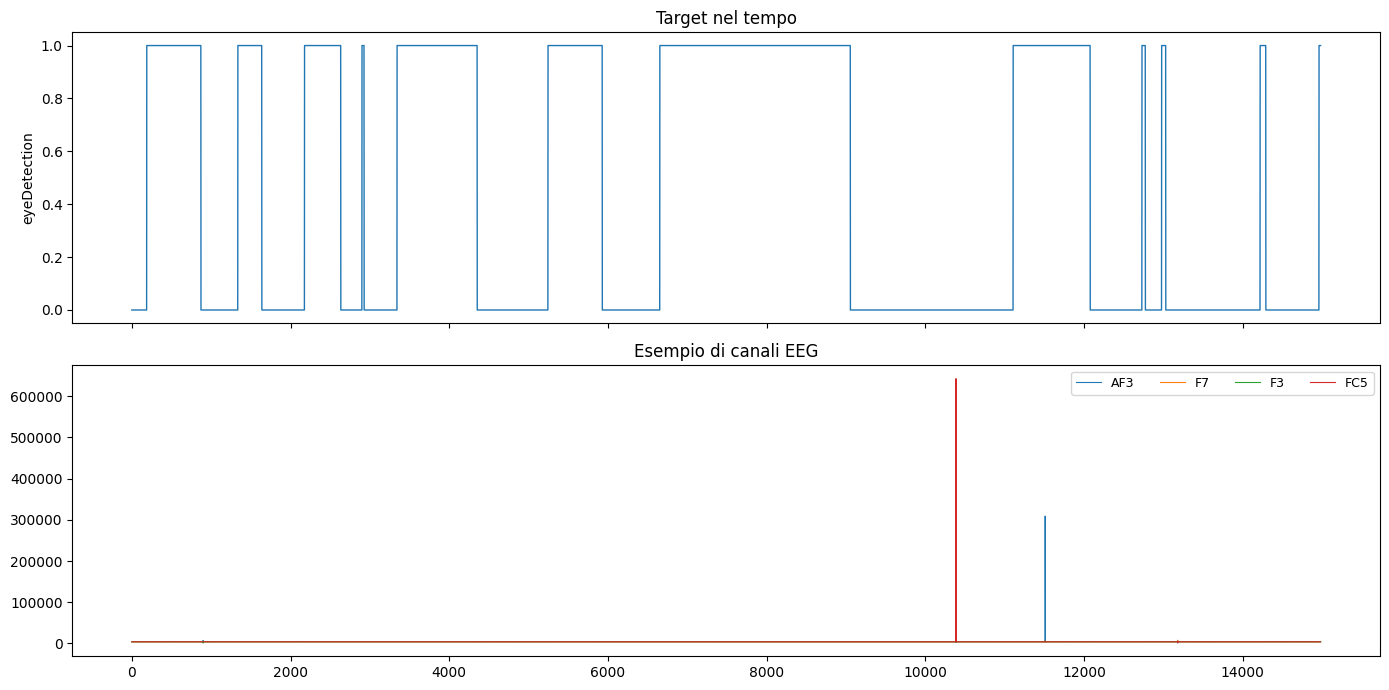

In [5]:
print("Shape:", df.shape)
print("Missing values per column:")
display(df.isna().sum().to_frame("missing"))

print("\nClass balance:")
display(df[target_col].value_counts(normalize=True).sort_index().rename("proportion").to_frame())

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
axes[0].plot(df["time_idx"], df[target_col], lw=1)
axes[0].set_title("Target nel tempo")
axes[0].set_ylabel(target_col)

for c in feature_cols[:min(4, len(feature_cols))]:
    axes[1].plot(df["time_idx"], df[c], lw=0.8, label=c)
axes[1].set_title("Esempio di canali EEG")
axes[1].legend(ncol=4, fontsize=9)
plt.tight_layout()
plt.show()

## Protocollo rigoroso di split

Per rispettare la richiesta originale e tenere una validation onesta:

- **55% iniziale** → `train_core`
- **15% successivo** → `validation`
- **30% finale** → `test`

Il test rimane l'**ultimo 30% cronologico untouched**.

Le finestre vengono assegnate allo split in base al loro **indice finale** (`end_idx`).
Questo significa che una finestra di test può usare storia immediatamente precedente al boundary, che è realistico:
al tempo `t` si può usare il passato fino a `t`, ma **mai il futuro**.

In [6]:
# =========================
# 3) Config principale
# =========================

RAW_TRAIN_CORE_FRAC = 0.55
RAW_VAL_FRAC = 0.15
RAW_TEST_FRAC = 0.30

assert abs(RAW_TRAIN_CORE_FRAC + RAW_VAL_FRAC + RAW_TEST_FRAC - 1.0) < 1e-9

N_ROWS = len(df)
TRAIN_CORE_END = int(math.floor(N_ROWS * RAW_TRAIN_CORE_FRAC))
TRAIN_FULL_END = int(math.floor(N_ROWS * (RAW_TRAIN_CORE_FRAC + RAW_VAL_FRAC)))  # first 70%
TEST_START = TRAIN_FULL_END

print("N_ROWS:", N_ROWS)
print("TRAIN_CORE_END:", TRAIN_CORE_END)
print("TRAIN_FULL_END:", TRAIN_FULL_END)
print("TEST_START:", TEST_START)
print("Test rows:", N_ROWS - TEST_START, f"({(N_ROWS - TEST_START)/N_ROWS:.1%})")

# Window config
WINDOW_SIZE = 128      # ~1 secondo se il sampling rate è circa 128 Hz
STRIDE = 8
LABEL_MODE = "majority"   # "majority" oppure "last"
FS_ASSUMED = 128          # usato solo per feature spettrali; modifica se hai metadata diversi

# Deep learning config
FAST_MODE = True
MAX_EPOCHS = 18 if FAST_MODE else 36
BATCH_SIZE = 128
PATIENCE = 5
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

# Modelli da lanciare
RUN_XGBOOST = True
RUN_EEGNET = True
RUN_TCN = True
RUN_INCEPTION = True
RUN_PATCHTST = True   # se CPU lenta, mettilo a False

N_ROWS: 14980
TRAIN_CORE_END: 8239
TRAIN_FULL_END: 10486
TEST_START: 10486
Test rows: 4494 (30.0%)


In [7]:
# =========================
# 4) Windowing causale
# =========================

def majority_or_last(y_window):
    ones = int(y_window.sum())
    zeros = len(y_window) - ones
    if ones > zeros:
        return 1
    if zeros > ones:
        return 0
    return int(y_window[-1])

def build_window_dataset(df, feature_cols, target_col, window_size=128, stride=8, label_mode="majority"):
    X_raw = df[feature_cols].to_numpy(dtype=np.float32)
    y_raw = df[target_col].to_numpy(dtype=np.int64)

    end_idx = np.arange(window_size - 1, len(df), stride, dtype=np.int64)
    start_idx = end_idx - window_size + 1

    X_seq = np.empty((len(end_idx), len(feature_cols), window_size), dtype=np.float32)
    y_seq = np.empty(len(end_idx), dtype=np.int64)

    for i, (s, e) in enumerate(zip(start_idx, end_idx)):
        window_x = X_raw[s:e+1].T   # [C, T]
        window_y = y_raw[s:e+1]

        X_seq[i] = window_x
        if label_mode == "last":
            y_seq[i] = int(window_y[-1])
        else:
            y_seq[i] = majority_or_last(window_y)

    return X_seq, y_seq, start_idx, end_idx

X_seq_all, y_seq_all, start_idx_all, end_idx_all = build_window_dataset(
    df=df,
    feature_cols=feature_cols,
    target_col=target_col,
    window_size=WINDOW_SIZE,
    stride=STRIDE,
    label_mode=LABEL_MODE,
)

split_name = np.where(
    end_idx_all < TRAIN_CORE_END,
    "train_core",
    np.where(end_idx_all < TRAIN_FULL_END, "val", "test")
)

print("Window tensor shape:", X_seq_all.shape)
print("Window labels shape:", y_seq_all.shape)
print(pd.Series(split_name).value_counts())

meta_windows = pd.DataFrame({
    "start_idx": start_idx_all,
    "end_idx": end_idx_all,
    "split": split_name,
    "y": y_seq_all,
})
display(meta_windows.head())

Window tensor shape: (1857, 14, 128)
Window labels shape: (1857,)
train_core    1014
test           562
val            281
Name: count, dtype: int64


,start_idx,end_idx,split,y
0,0,127,train_core,0
1,8,135,train_core,0
2,16,143,train_core,0
3,24,151,train_core,0
4,32,159,train_core,0


In [8]:
# Verifica: il test è davvero il last 30% per endpoint
assert (end_idx_all[split_name == "test"] >= TEST_START).all()
assert (end_idx_all[split_name == "train_core"] < TRAIN_CORE_END).all()
assert ((end_idx_all[split_name == "val"] >= TRAIN_CORE_END) & (end_idx_all[split_name == "val"] < TRAIN_FULL_END)).all()

print("Split checks passed.")

Split checks passed.


## Feature engineering causale per il baseline tabellare

Costruiamo feature più forti del semplice sample-by-sample:

- statistiche per canale sulla finestra
- trend e variabilità locale
- energia / line length / differenze assolute
- quantili
- bandpower spettrali causali
- asimmetrie tra coppie di elettrodi sinistra-destra, quando disponibili

In [9]:
# =========================
# 5) Feature engineering tabellare
# =========================

LEFT_RIGHT_PAIRS = [
    ("AF3", "AF4"),
    ("F7", "F8"),
    ("F3", "F4"),
    ("FC5", "FC6"),
    ("T7", "T8"),
    ("P7", "P8"),
    ("O1", "O2"),
]

def compute_bandpower_features(X_seq, fs=128):
    # X_seq: [N, C, T]
    spec = np.fft.rfft(X_seq, axis=-1)
    power = (np.abs(spec) ** 2).astype(np.float32)
    freqs = np.fft.rfftfreq(X_seq.shape[-1], d=1.0 / fs)

    bands = {
        "delta": (0.5, 4.0),
        "theta": (4.0, 8.0),
        "alpha": (8.0, 13.0),
        "beta":  (13.0, 30.0),
    }

    total_power = power.sum(axis=-1) + 1e-8
    out = {}
    for band_name, (f0, f1) in bands.items():
        mask = (freqs >= f0) & (freqs < f1)
        if mask.sum() == 0:
            bp = np.zeros(power.shape[:2], dtype=np.float32)
        else:
            bp = power[..., mask].sum(axis=-1).astype(np.float32)
        out[f"{band_name}_abs"] = bp
        out[f"{band_name}_rel"] = (bp / total_power).astype(np.float32)
    return out

def extract_tabular_features(X_seq, feature_cols, fs=128):
    # X_seq: [N, C, T]
    N, C, T = X_seq.shape
    eps = 1e-8

    mean_ = X_seq.mean(axis=-1)
    std_ = X_seq.std(axis=-1)
    min_ = X_seq.min(axis=-1)
    max_ = X_seq.max(axis=-1)
    q25_ = np.quantile(X_seq, 0.25, axis=-1)
    q75_ = np.quantile(X_seq, 0.75, axis=-1)
    last_ = X_seq[:, :, -1]
    first_ = X_seq[:, :, 0]
    delta_ = last_ - first_
    madiff_ = np.mean(np.abs(np.diff(X_seq, axis=-1)), axis=-1)
    line_length_ = np.sum(np.abs(np.diff(X_seq, axis=-1)), axis=-1)
    energy_ = np.mean(X_seq ** 2, axis=-1)

    # trend lineare semplice per canale
    t = np.arange(T, dtype=np.float32)
    t_centered = t - t.mean()
    denom = float((t_centered ** 2).sum()) + eps
    slope_ = np.tensordot(X_seq, t_centered, axes=([-1], [0])) / denom

    band_feats = compute_bandpower_features(X_seq, fs=fs)

    data = {}
    stat_tensors = {
        "mean": mean_,
        "std": std_,
        "min": min_,
        "max": max_,
        "q25": q25_,
        "q75": q75_,
        "first": first_,
        "last": last_,
        "delta": delta_,
        "madiff": madiff_,
        "line_length": line_length_,
        "energy": energy_,
        "slope": slope_,
    }

    for stat_name, arr in stat_tensors.items():
        for j, ch in enumerate(feature_cols):
            data[f"{ch}__{stat_name}"] = arr[:, j]

    for feat_name, arr in band_feats.items():
        for j, ch in enumerate(feature_cols):
            data[f"{ch}__{feat_name}"] = arr[:, j]

    # asimmetrie sinistra-destra
    channel_to_idx = {ch: i for i, ch in enumerate(feature_cols)}
    for left, right in LEFT_RIGHT_PAIRS:
        if left in channel_to_idx and right in channel_to_idx:
            li = channel_to_idx[left]
            ri = channel_to_idx[right]
            data[f"{left}_{right}__mean_diff"] = mean_[:, li] - mean_[:, ri]
            data[f"{left}_{right}__last_diff"] = last_[:, li] - last_[:, ri]
            data[f"{left}_{right}__alpha_rel_diff"] = band_feats["alpha_rel"][:, li] - band_feats["alpha_rel"][:, ri]
            data[f"{left}_{right}__beta_rel_diff"] = band_feats["beta_rel"][:, li] - band_feats["beta_rel"][:, ri]

    feat_df = pd.DataFrame(data).replace([np.inf, -np.inf], np.nan).fillna(0.0)
    return feat_df.astype(np.float32)

X_tab_all = extract_tabular_features(X_seq_all, feature_cols=feature_cols, fs=FS_ASSUMED)
print("Tabular feature matrix shape:", X_tab_all.shape)
display(X_tab_all.head())

Tabular feature matrix shape: (1857, 322)


,AF3__mean,F7__mean,F3__mean,FC5__mean,T7__mean,P7__mean,O1__mean,O2__mean,P8__mean,T8__mean,FC6__mean,F4__mean,F8__mean,AF4__mean,AF3__std,F7__std,F3__std,FC5__std,T7__std,P7__std,O1__std,O2__std,P8__std,T8__std,FC6__std,F4__std,F8__std,AF4__std,AF3__min,F7__min,F3__min,FC5__min,T7__min,P7__min,O1__min,O2__min,P8__min,T8__min,FC6__min,F4__min,F8__min,AF4__min,AF3__max,F7__max,F3__max,FC5__max,T7__max,P7__max,O1__max,O2__max,P8__max,T8__max,FC6__max,F4__max,F8__max,AF4__max,AF3__q25,F7__q25,F3__q25,FC5__q25,T7__q25,P7__q25,O1__q25,O2__q25,P8__q25,T8__q25,FC6__q25,F4__q25,F8__q25,AF4__q25,AF3__q75,F7__q75,F3__q75,FC5__q75,T7__q75,P7__q75,O1__q75,O2__q75,P8__q75,T8__q75,FC6__q75,F4__q75,F8__q75,AF4__q75,AF3__first,F7__first,F3__first,FC5__first,T7__first,P7__first,O1__first,O2__first,P8__first,T8__first,FC6__first,F4__first,F8__first,AF4__first,AF3__last,F7__last,...,F8__theta_abs,AF4__theta_abs,AF3__theta_rel,F7__theta_rel,F3__theta_rel,FC5__theta_rel,T7__theta_rel,P7__theta_rel,O1__theta_rel,O2__theta_rel,P8__theta_rel,T8__theta_rel,FC6__theta_rel,F4__theta_rel,F8__theta_rel,AF4__theta_rel,AF3__alpha_abs,F7__alpha_abs,F3__alpha_abs,FC5__alpha_abs,T7__alpha_abs,P7__alpha_abs,O1__alpha_abs,O2__alpha_abs,P8__alpha_abs,T8__alpha_abs,FC6__alpha_abs,F4__alpha_abs,F8__alpha_abs,AF4__alpha_abs,AF3__alpha_rel,F7__alpha_rel,F3__alpha_rel,FC5__alpha_rel,T7__alpha_rel,P7__alpha_rel,O1__alpha_rel,O2__alpha_rel,P8__alpha_rel,T8__alpha_rel,FC6__alpha_rel,F4__alpha_rel,F8__alpha_rel,AF4__alpha_rel,AF3__beta_abs,F7__beta_abs,F3__beta_abs,FC5__beta_abs,T7__beta_abs,P7__beta_abs,O1__beta_abs,O2__beta_abs,P8__beta_abs,T8__beta_abs,FC6__beta_abs,F4__beta_abs,F8__beta_abs,AF4__beta_abs,AF3__beta_rel,F7__beta_rel,F3__beta_rel,FC5__beta_rel,T7__beta_rel,P7__beta_rel,O1__beta_rel,O2__beta_rel,P8__beta_rel,T8__beta_rel,FC6__beta_rel,F4__beta_rel,F8__beta_rel,AF4__beta_rel,AF3_AF4__mean_diff,AF3_AF4__last_diff,AF3_AF4__alpha_rel_diff,AF3_AF4__beta_rel_diff,F7_F8__mean_diff,F7_F8__last_diff,F7_F8__alpha_rel_diff,F7_F8__beta_rel_diff,F3_F4__mean_diff,F3_F4__last_diff,F3_F4__alpha_rel_diff,F3_F4__beta_rel_diff,FC5_FC6__mean_diff,FC5_FC6__last_diff,FC5_FC6__alpha_rel_diff,FC5_FC6__beta_rel_diff,T7_T8__mean_diff,T7_T8__last_diff,T7_T8__alpha_rel_diff,T7_T8__beta_rel_diff,P7_P8__mean_diff,P7_P8__last_diff,P7_P8__alpha_rel_diff,P7_P8__beta_rel_diff,O1_O2__mean_diff,O1_O2__last_diff,O1_O2__alpha_rel_diff,O1_O2__beta_rel_diff
0,4310.112793,4006.638672,4265.697266,4130.561035,4339.895996,4595.324707,4090.112305,4620.184082,4204.699219,4229.699707,4207.315430,4276.290039,4619.919922,4370.572754,10.060184,7.229057,12.229359,9.777987,6.188829,10.126403,6.462405,8.895700,10.786524,10.046358,10.013970,10.791723,10.564367,12.750490,4281.540039,3992.310059,4244.100098,4105.640137,4324.620117,4577.950195,4075.379883,4592.819824,4176.919922,4204.620117,4186.149902,4252.819824,4597.950195,4345.640137,4335.899902,4026.149902,4296.410156,4156.410156,4356.919922,4615.899902,4109.740234,4641.029785,4231.790039,4252.819824,4228.209961,4300.509766,4640.000000,4401.540039,4303.589844,4002.050049,4257.182617,4122.560059,4335.252441,4585.640137,4086.149902,4614.359863,4197.822754,4222.432617,4198.842773,4269.102539,4611.279785,4360.382324,4315.899902,4010.770020,4276.537598,4137.439941,4344.620117,4603.847656,4094.487549,4626.535156,4212.437500,4237.439941,4213.977539,4284.100098,4628.337402,4380.000000,4329.229980,4009.229980,4289.229980,4148.209961,4350.259766,4586.149902,4096.919922,4641.029785,4222.049805,4238.459961,4211.279785,4280.509766,4635.899902,4393.850098,4287.180176,3992.310059,...,83794.273438,1.029698e+05,2.679975e-07,1.626338e-07,1.045500e-06,6.361332e-07,1.182643e-07,2.100418e-07,1.046516e-07,2.934297e-07,3.208653e-07,1.806352e-07,3.445138e-07,4.633322e-07,2.396207e-07,3.290118e-07,268355.562500,127546.398438,330062.375000,131875.187500,37209.621094,57590.187500,80602.507812,219803.984375,338098.37500,404239.96875,364296.15625,237679.500000,489108.18750,430673.125

In [10]:
# =========================
# 6) Split tabellare / sequenziale
# =========================

train_core_mask = split_name == "train_core"
val_mask = split_name == "val"
test_mask = split_name == "test"
pretest_mask = split_name != "test"

X_tab_train_core = X_tab_all.loc[train_core_mask].reset_index(drop=True)
y_train_core = y_seq_all[train_core_mask]

X_tab_val = X_tab_all.loc[val_mask].reset_index(drop=True)
y_val = y_seq_all[val_mask]

X_tab_pretest = X_tab_all.loc[pretest_mask].reset_index(drop=True)
y_pretest = y_seq_all[pretest_mask]

X_tab_test = X_tab_all.loc[test_mask].reset_index(drop=True)
y_test = y_seq_all[test_mask]

X_seq_train_core = X_seq_all[train_core_mask]
X_seq_val = X_seq_all[val_mask]
X_seq_pretest = X_seq_all[pretest_mask]
X_seq_test = X_seq_all[test_mask]

print("Tabular train_core / val / test:", X_tab_train_core.shape, X_tab_val.shape, X_tab_test.shape)
print("Sequence train_core / val / test:", X_seq_train_core.shape, X_seq_val.shape, X_seq_test.shape)

Tabular train_core / val / test: (1014, 322) (281, 322) (562, 322)
Sequence train_core / val / test: (1014, 14, 128) (281, 14, 128) (562, 14, 128)


In [11]:
# =========================
# 7) Standardizzazione per deep learning
#     fit solo sul passato
# =========================

def fit_channel_standardizer_from_raw_rows(df, feature_cols, end_exclusive):
    stats = df.loc[:end_exclusive - 1, feature_cols].agg(["mean", "std"])
    mean = stats.loc["mean"].to_numpy(dtype=np.float32)
    std = stats.loc["std"].replace(0, 1.0).to_numpy(dtype=np.float32)
    std = np.where(std < 1e-6, 1.0, std).astype(np.float32)
    return mean, std

def transform_seq_with_channel_stats(X_seq, mean, std):
    return ((X_seq - mean[None, :, None]) / std[None, :, None]).astype(np.float32)

ch_mean_train_core, ch_std_train_core = fit_channel_standardizer_from_raw_rows(df, feature_cols, TRAIN_CORE_END)
ch_mean_pretest, ch_std_pretest = fit_channel_standardizer_from_raw_rows(df, feature_cols, TRAIN_FULL_END)

X_seq_train_core_std = transform_seq_with_channel_stats(X_seq_train_core, ch_mean_train_core, ch_std_train_core)
X_seq_val_std = transform_seq_with_channel_stats(X_seq_val, ch_mean_train_core, ch_std_train_core)

# per il refit finale si userà la standardizzazione fit sui primi 70%
X_seq_pretest_std = transform_seq_with_channel_stats(X_seq_pretest, ch_mean_pretest, ch_std_pretest)
X_seq_test_std = transform_seq_with_channel_stats(X_seq_test, ch_mean_pretest, ch_std_pretest)

print("Standardization ready.")

Standardization ready.


## Utility di valutazione e post-processing causale

Facciamo due cose **solo sulla validation**:

1. **threshold tuning**
2. **smoothing causale** delle probabilità

Lo smoothing è utile perché l'eye state non cambia in modo casuale a ogni singolo sample.

In [12]:
# =========================
# 8) Utility metriche / smoothing / threshold
# =========================

def ewma_causal(probs, span=1):
    probs = np.asarray(probs, dtype=np.float32)
    if span <= 1:
        return probs.copy()
    alpha = 2.0 / (span + 1.0)
    out = np.empty_like(probs, dtype=np.float32)
    out[0] = probs[0]
    for i in range(1, len(probs)):
        out[i] = alpha * probs[i] + (1.0 - alpha) * out[i - 1]
    return out

def summarize_metrics(y_true, probs, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    probs = np.asarray(probs, dtype=np.float32)
    preds = (probs >= threshold).astype(int)

    out = {}
    out["accuracy"] = accuracy_score(y_true, preds)
    out["balanced_accuracy"] = balanced_accuracy_score(y_true, preds)
    out["mcc"] = matthews_corrcoef(y_true, preds)
    out["f1_pos"] = f1_score(y_true, preds, pos_label=1, zero_division=0)
    out["macro_f1"] = f1_score(y_true, preds, average="macro", zero_division=0)
    out["weighted_f1"] = f1_score(y_true, preds, average="weighted", zero_division=0)
    out["precision_pos"] = precision_score(y_true, preds, pos_label=1, zero_division=0)
    out["recall_pos"] = recall_score(y_true, preds, pos_label=1, zero_division=0)

    if len(np.unique(y_true)) == 2:
        out["roc_auc"] = roc_auc_score(y_true, probs)
        out["pr_auc"] = average_precision_score(y_true, probs)
    else:
        out["roc_auc"] = np.nan
        out["pr_auc"] = np.nan

    tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
    out["tn"] = tn
    out["fp"] = fp
    out["fn"] = fn
    out["tp"] = tp
    return out

def search_best_postprocess(y_true, probs, spans=(1, 3, 5, 9, 15), thresholds=None, objective="macro_f1"):
    if thresholds is None:
        thresholds = np.linspace(0.10, 0.90, 81)

    best = None
    for span in spans:
        sm = ewma_causal(probs, span=span)
        for thr in thresholds:
            metrics = summarize_metrics(y_true, sm, threshold=float(thr))
            score = metrics[objective]
            if (best is None) or (score > best["score"]):
                best = {
                    "span": int(span),
                    "threshold": float(thr),
                    "score": float(score),
                    "metrics": metrics,
                    "smoothed_probs": sm,
                }
    return best

def make_metrics_row(model_name, split_name, threshold, span, metrics):
    row = {
        "model": model_name,
        "split": split_name,
        "threshold": threshold,
        "smooth_span": span,
    }
    row.update(metrics)
    return row

## Baseline forte: XGBoost sulle feature causali

È il baseline ML forte del notebook.
Poi lo confrontiamo con i modelli deep learning.

In [13]:
# =========================
# 9) XGBoost con tuning solo su validation
# =========================

xgb_search_space = [
    {"max_depth": 3, "learning_rate": 0.03, "min_child_weight": 1, "subsample": 0.85, "colsample_bytree": 0.85},
    {"max_depth": 4, "learning_rate": 0.03, "min_child_weight": 3, "subsample": 0.85, "colsample_bytree": 0.85},
    {"max_depth": 4, "learning_rate": 0.05, "min_child_weight": 5, "subsample": 0.90, "colsample_bytree": 0.90},
    {"max_depth": 5, "learning_rate": 0.03, "min_child_weight": 5, "subsample": 0.80, "colsample_bytree": 0.80},
]

xgb_artifact = None

if RUN_XGBOOST:
    neg = int((y_train_core == 0).sum())
    pos = int((y_train_core == 1).sum())
    scale_pos_weight = max(1.0, neg / max(pos, 1))

    xgb_trials = []
    for i, cfg in enumerate(xgb_search_space, start=1):
        model = xgb.XGBClassifier(
            objective="binary:logistic",
            eval_metric="aucpr",
            tree_method="hist",
            n_estimators=1500,
            max_depth=cfg["max_depth"],
            learning_rate=cfg["learning_rate"],
            min_child_weight=cfg["min_child_weight"],
            subsample=cfg["subsample"],
            colsample_bytree=cfg["colsample_bytree"],
            reg_alpha=0.5,
            reg_lambda=2.0,
            gamma=0.0,
            random_state=SEED,
            early_stopping_rounds=80,
            scale_pos_weight=scale_pos_weight,
        )

        model.fit(
            X_tab_train_core, y_train_core,
            eval_set=[(X_tab_val, y_val)],
            verbose=False,
        )

        val_probs = model.predict_proba(X_tab_val)[:, 1]
        post = search_best_postprocess(y_val, val_probs, objective="macro_f1")
        row = make_metrics_row("xgboost", "val", post["threshold"], post["span"], post["metrics"])
        row["best_iteration"] = int(getattr(model, "best_iteration", model.n_estimators))
        row["cfg"] = cfg
        xgb_trials.append((row, model, val_probs, post))

    xgb_trials_sorted = sorted(xgb_trials, key=lambda x: x[0]["macro_f1"], reverse=True)
    best_row, best_model, best_val_probs, best_post = xgb_trials_sorted[0]

    best_cfg = best_row["cfg"]
    best_iteration = max(50, int(best_row["best_iteration"]))

    # Refit finale sui primi 70% con i migliori iperparametri, senza toccare il test
    neg_pre = int((y_pretest == 0).sum())
    pos_pre = int((y_pretest == 1).sum())
    scale_pos_weight_pre = max(1.0, neg_pre / max(pos_pre, 1))

    xgb_final = xgb.XGBClassifier(
        objective="binary:logistic",
        eval_metric="aucpr",
        tree_method="hist",
        n_estimators=best_iteration,
        max_depth=best_cfg["max_depth"],
        learning_rate=best_cfg["learning_rate"],
        min_child_weight=best_cfg["min_child_weight"],
        subsample=best_cfg["subsample"],
        colsample_bytree=best_cfg["colsample_bytree"],
        reg_alpha=0.5,
        reg_lambda=2.0,
        gamma=0.0,
        random_state=SEED,
        scale_pos_weight=scale_pos_weight_pre,
    )
    xgb_final.fit(X_tab_pretest, y_pretest, verbose=False)
    test_probs = xgb_final.predict_proba(X_tab_test)[:, 1]
    test_probs_sm = ewma_causal(test_probs, span=best_post["span"])
    test_metrics = summarize_metrics(y_test, test_probs_sm, threshold=best_post["threshold"])

    xgb_artifact = {
        "name": "xgboost",
        "cfg": best_cfg,
        "best_iteration": best_iteration,
        "val_probs": best_post["smoothed_probs"],
        "val_raw_probs": best_val_probs,
        "val_threshold": best_post["threshold"],
        "val_span": best_post["span"],
        "val_metrics": best_post["metrics"],
        "test_probs": test_probs_sm,
        "test_raw_probs": test_probs,
        "test_metrics": test_metrics,
        "final_model": xgb_final,
    }

    print("Best XGBoost config:", best_cfg)
    print("Best iteration:", best_iteration)
    print(pd.DataFrame([
        make_metrics_row("xgboost", "val", best_post["threshold"], best_post["span"], best_post["metrics"]),
        make_metrics_row("xgboost", "test", best_post["threshold"], best_post["span"], test_metrics),
    ]))

Best XGBoost config: {'max_depth': 4, 'learning_rate': 0.05, 'min_child_weight': 5, 'subsample': 0.9, 'colsample_bytree': 0.9}
Best iteration: 50
     model split  threshold  smooth_span  accuracy  balanced_accuracy       mcc    f1_pos  macro_f1  weighted_f1  precision_pos  recall_pos   roc_auc    pr_auc   tn   fp  fn  tp
0  xgboost   val        0.6           15  0.754448           0.775545  0.539457  0.735632  0.753198     0.757011       0.635762    0.872727  0.831419  0.747474  116   55  14  96
1  xgboost  test        0.6           15  0.695730           0.624626  0.229199  0.428094  0.610410     0.708381       0.378698    0.492308  0.585470  0.409156  327  105  66  64


## Modelli deep learning

Qui usiamo quattro famiglie di modelli:

- **EEGNet-like**: specifico per EEG, compatto
- **TCN**: convoluzioni dilatate per dipendenze temporali
- **InceptionTime-like**: molto forte nelle time series classification
- **PatchTST-lite**: trasformer a patch, lasciato come opzione moderna

Tutti i modelli:
- usano **solo train_core** per scegliere epoca migliore / impostazione
- usano **validation** solo per threshold e smoothing
- vengono **rifittati sui primi 70%** prima del test finale

In [14]:
# =========================
# 10) DataLoader utilities
# =========================

def make_loader(X, y, batch_size=128, shuffle=False):
    X_t = torch.tensor(X, dtype=torch.float32)
    y_t = torch.tensor(y, dtype=torch.float32)
    ds = TensorDataset(X_t, y_t)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, drop_last=False)

def sigmoid_np(x):
    return 1.0 / (1.0 + np.exp(-x))

@torch.no_grad()
def predict_proba_torch(model, loader, device=DEVICE):
    model.eval()
    probs = []
    ys = []
    for xb, yb in loader:
        xb = xb.to(device)
        logits = model(xb)
        p = torch.sigmoid(logits).detach().cpu().numpy()
        probs.append(p)
        ys.append(yb.numpy())
    probs = np.concatenate(probs)
    ys = np.concatenate(ys).astype(int)
    return probs.astype(np.float32), ys

def fit_torch_model(
    model,
    X_train,
    y_train,
    X_val,
    y_val,
    max_epochs=20,
    batch_size=128,
    lr=1e-3,
    weight_decay=1e-4,
    patience=5,
    verbose=True,
):
    train_loader = make_loader(X_train, y_train, batch_size=batch_size, shuffle=False)
    val_loader = make_loader(X_val, y_val, batch_size=batch_size, shuffle=False)

    pos = float((y_train == 1).sum())
    neg = float((y_train == 0).sum())
    pos_weight_value = max(1.0, neg / max(pos, 1.0))
    pos_weight = torch.tensor([pos_weight_value], dtype=torch.float32, device=DEVICE)

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_score = -np.inf
    best_state = None
    best_epoch = 0
    history = []

    for epoch in range(1, max_epochs + 1):
        model.train()
        train_losses = []

        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_losses.append(float(loss.item()))

        val_probs, _ = predict_proba_torch(model, val_loader, device=DEVICE)
        try:
            val_score = average_precision_score(y_val, val_probs)
        except Exception:
            val_score = 0.0

        history.append({
            "epoch": epoch,
            "train_loss": float(np.mean(train_losses)),
            "val_pr_auc": float(val_score),
        })

        if val_score > best_score:
            best_score = val_score
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch

        if verbose:
            print(
                f"epoch={epoch:02d} "
                f"train_loss={np.mean(train_losses):.4f} "
                f"val_pr_auc={val_score:.4f} "
                f"best_epoch={best_epoch}"
            )

        if epoch - best_epoch >= patience:
            if verbose:
                print("Early stopping.")
            break

    model.load_state_dict(best_state)
    val_probs, _ = predict_proba_torch(model, val_loader, device=DEVICE)

    return {
        "model": model,
        "history": pd.DataFrame(history),
        "best_epoch": int(best_epoch),
        "val_probs_raw": val_probs,
    }

def refit_torch_model_full(
    model_builder,
    model_kwargs,
    X_pretest,
    y_pretest,
    n_epochs,
    batch_size=128,
    lr=1e-3,
    weight_decay=1e-4,
    verbose=False,
):
    model = model_builder(**model_kwargs).to(DEVICE)
    loader = make_loader(X_pretest, y_pretest, batch_size=batch_size, shuffle=False)

    pos = float((y_pretest == 1).sum())
    neg = float((y_pretest == 0).sum())
    pos_weight_value = max(1.0, neg / max(pos, 1.0))
    pos_weight = torch.tensor([pos_weight_value], dtype=torch.float32, device=DEVICE)

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    model.train()
    for epoch in range(1, n_epochs + 1):
        losses = []
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            losses.append(float(loss.item()))
        if verbose:
            print(f"[refit] epoch={epoch:02d} loss={np.mean(losses):.4f}")
    return model

In [15]:
# =========================
# 11) Architetture deep learning
# =========================

class EEGNetLite(nn.Module):
    def __init__(self, n_channels, n_times, F1=8, D=2, F2=16, kernel_length=64, dropout=0.35):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(1, F1, kernel_size=(1, kernel_length), padding=(0, kernel_length // 2), bias=False),
            nn.BatchNorm2d(F1),
            nn.Conv2d(F1, F1 * D, kernel_size=(n_channels, 1), groups=F1, bias=False),
            nn.BatchNorm2d(F1 * D),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1, 4)),
            nn.Dropout(dropout),
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(F1 * D, F1 * D, kernel_size=(1, 16), padding=(0, 8), groups=F1 * D, bias=False),
            nn.Conv2d(F1 * D, F2, kernel_size=1, bias=False),
            nn.BatchNorm2d(F2),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1, 8)),
            nn.Dropout(dropout),
        )
        with torch.no_grad():
            dummy = torch.zeros(1, 1, n_channels, n_times)
            n_out = self.block2(self.block1(dummy)).flatten(1).shape[1]
        self.classifier = nn.Linear(n_out, 1)

    def forward(self, x):
        x = x.unsqueeze(1)  # [B, 1, C, T]
        x = self.block1(x)
        x = self.block2(x)
        x = x.flatten(1)
        return self.classifier(x).squeeze(-1)


class Chomp1d(nn.Module):
    def __init__(self, chomp_size):
        super().__init__()
        self.chomp_size = chomp_size
    def forward(self, x):
        return x if self.chomp_size == 0 else x[:, :, :-self.chomp_size]


class TemporalBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=5, dilation=1, dropout=0.2):
        super().__init__()
        pad = (kernel_size - 1) * dilation
        self.net = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel_size, padding=pad, dilation=dilation),
            Chomp1d(pad),
            nn.BatchNorm1d(out_ch),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Conv1d(out_ch, out_ch, kernel_size, padding=pad, dilation=dilation),
            Chomp1d(pad),
            nn.BatchNorm1d(out_ch),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        self.downsample = nn.Conv1d(in_ch, out_ch, kernel_size=1) if in_ch != out_ch else nn.Identity()
        self.act = nn.GELU()

    def forward(self, x):
        return self.act(self.net(x) + self.downsample(x))


class TCNClassifier(nn.Module):
    def __init__(self, n_channels, channels=(32, 32, 64), kernel_size=5, dropout=0.25):
        super().__init__()
        layers = []
        in_ch = n_channels
        for i, out_ch in enumerate(channels):
            layers.append(TemporalBlock(in_ch, out_ch, kernel_size=kernel_size, dilation=2**i, dropout=dropout))
            in_ch = out_ch
        self.backbone = nn.Sequential(*layers)
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Linear(in_ch, 1)
        )

    def forward(self, x):
        x = self.backbone(x)
        return self.head(x).squeeze(-1)


class InceptionModule(nn.Module):
    def __init__(self, in_ch, bottleneck=32, out_ch=32, kernel_sizes=(9, 19, 39)):
        super().__init__()
        self.use_bottleneck = in_ch > 1
        if self.use_bottleneck:
            self.bottleneck = nn.Conv1d(in_ch, bottleneck, kernel_size=1, bias=False)
            conv_in = bottleneck
        else:
            self.bottleneck = nn.Identity()
            conv_in = in_ch

        self.convs = nn.ModuleList([
            nn.Conv1d(conv_in, out_ch, kernel_size=k, padding=k // 2, bias=False) for k in kernel_sizes
        ])
        self.pool_conv = nn.Sequential(
            nn.MaxPool1d(kernel_size=3, stride=1, padding=1),
            nn.Conv1d(in_ch, out_ch, kernel_size=1, bias=False)
        )
        self.bn = nn.BatchNorm1d(out_ch * (len(kernel_sizes) + 1))
        self.act = nn.ReLU()

    def forward(self, x):
        z = self.bottleneck(x)
        out = [conv(z) for conv in self.convs]
        out.append(self.pool_conv(x))
        out = torch.cat(out, dim=1)
        out = self.bn(out)
        return self.act(out)


class InceptionBlock(nn.Module):
    def __init__(self, in_ch, depth=3, bottleneck=32, out_ch=32):
        super().__init__()
        self.depth = depth
        modules = []
        channels = [in_ch]
        current_in = in_ch
        for _ in range(depth):
            m = InceptionModule(current_in, bottleneck=bottleneck, out_ch=out_ch)
            modules.append(m)
            current_in = out_ch * 4
            channels.append(current_in)
        self.modules_list = nn.ModuleList(modules)
        self.residual = nn.Conv1d(in_ch, current_in, kernel_size=1) if in_ch != current_in else nn.Identity()
        self.act = nn.ReLU()

    def forward(self, x):
        inp = x
        for m in self.modules_list:
            x = m(x)
        return self.act(x + self.residual(inp))


class InceptionTimeClassifier(nn.Module):
    def __init__(self, n_channels, blocks=2, bottleneck=32, out_ch=32, dropout=0.2):
        super().__init__()
        layers = []
        in_ch = n_channels
        for _ in range(blocks):
            layers.append(InceptionBlock(in_ch, depth=3, bottleneck=bottleneck, out_ch=out_ch))
            in_ch = out_ch * 4
        self.backbone = nn.Sequential(*layers)
        self.dropout = nn.Dropout(dropout)
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Linear(in_ch, 1),
        )

    def forward(self, x):
        x = self.backbone(x)
        x = self.dropout(x)
        return self.head(x).squeeze(-1)


class PatchTSTLite(nn.Module):
    def __init__(self, n_channels, n_times, patch_len=16, stride=8, d_model=64, n_heads=4, depth=2, dropout=0.2):
        super().__init__()
        assert n_times >= patch_len, "patch_len must be <= window length"
        self.n_channels = n_channels
        self.patch_len = patch_len
        self.stride = stride
        self.n_patches = 1 + (n_times - patch_len) // stride

        self.patch_proj = nn.Linear(patch_len, d_model)
        self.channel_emb = nn.Embedding(n_channels, d_model)
        self.pos_emb = nn.Embedding(self.n_patches, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=d_model * 4,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=depth)
        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, 1)

    def forward(self, x):
        # x: [B, C, T]
        patches = x.unfold(dimension=-1, size=self.patch_len, step=self.stride)  # [B, C, Np, patch_len]
        B, C, Np, P = patches.shape
        tokens = self.patch_proj(patches.reshape(B, C * Np, P))

        channel_ids = torch.arange(C, device=x.device).repeat_interleave(Np)
        patch_ids = torch.arange(Np, device=x.device).repeat(C)

        tokens = tokens + self.channel_emb(channel_ids)[None, :, :] + self.pos_emb(patch_ids)[None, :, :]
        tokens = self.encoder(tokens)
        tokens = self.norm(tokens)
        pooled = tokens.mean(dim=1)
        return self.head(pooled).squeeze(-1)

In [16]:
# =========================
# 12) Ricerca + refit dei modelli deep learning
# =========================

results_rows = []
artifacts = {}

def run_single_dl_model(model_name, model_builder, model_kwargs, train_X, train_y, val_X, val_y, pretest_X, pretest_y, test_X, test_y):
    print("=" * 100)
    print("MODEL:", model_name)
    print("KWARGS:", model_kwargs)

    seed_everything(SEED)
    model = model_builder(**model_kwargs).to(DEVICE)

    fit_out = fit_torch_model(
        model=model,
        X_train=train_X,
        y_train=train_y,
        X_val=val_X,
        y_val=val_y,
        max_epochs=MAX_EPOCHS,
        batch_size=BATCH_SIZE,
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
        patience=PATIENCE,
        verbose=True,
    )

    val_raw_probs = fit_out["val_probs_raw"]
    best_epoch = fit_out["best_epoch"]
    best_post = search_best_postprocess(val_y, val_raw_probs, objective="macro_f1")

    val_row = make_metrics_row(model_name, "val", best_post["threshold"], best_post["span"], best_post["metrics"])
    val_row["best_epoch"] = best_epoch
    results_rows.append(val_row)

    print("\nValidation metrics:")
    display(pd.DataFrame([val_row]))

    seed_everything(SEED)
    final_model = refit_torch_model_full(
        model_builder=model_builder,
        model_kwargs=model_kwargs,
        X_pretest=pretest_X,
        y_pretest=pretest_y,
        n_epochs=best_epoch,
        batch_size=BATCH_SIZE,
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
        verbose=False,
    )

    test_loader = make_loader(test_X, test_y, batch_size=BATCH_SIZE, shuffle=False)
    test_raw_probs, _ = predict_proba_torch(final_model, test_loader, device=DEVICE)
    test_probs = ewma_causal(test_raw_probs, span=best_post["span"])
    test_metrics = summarize_metrics(test_y, test_probs, threshold=best_post["threshold"])

    test_row = make_metrics_row(model_name, "test", best_post["threshold"], best_post["span"], test_metrics)
    test_row["best_epoch"] = best_epoch
    results_rows.append(test_row)

    artifacts[model_name] = {
        "name": model_name,
        "model_kwargs": model_kwargs,
        "best_epoch": best_epoch,
        "val_raw_probs": val_raw_probs,
        "val_probs": best_post["smoothed_probs"],
        "val_threshold": best_post["threshold"],
        "val_span": best_post["span"],
        "val_metrics": best_post["metrics"],
        "test_raw_probs": test_raw_probs,
        "test_probs": test_probs,
        "test_metrics": test_metrics,
        "history": fit_out["history"],
        "final_model": final_model,
    }

    print("\nTest metrics:")
    display(pd.DataFrame([test_row]))
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


n_channels = len(feature_cols)
n_times = WINDOW_SIZE

if RUN_EEGNET:
    run_single_dl_model(
        model_name="eegnet",
        model_builder=EEGNetLite,
        model_kwargs=dict(n_channels=n_channels, n_times=n_times, F1=8, D=2, F2=16, kernel_length=64, dropout=0.35),
        train_X=X_seq_train_core_std,
        train_y=y_train_core,
        val_X=X_seq_val_std,
        val_y=y_val,
        pretest_X=X_seq_pretest_std,
        pretest_y=y_pretest,
        test_X=X_seq_test_std,
        test_y=y_test,
    )

if RUN_TCN:
    run_single_dl_model(
        model_name="tcn",
        model_builder=TCNClassifier,
        model_kwargs=dict(n_channels=n_channels, channels=(32, 32, 64), kernel_size=5, dropout=0.25),
        train_X=X_seq_train_core_std,
        train_y=y_train_core,
        val_X=X_seq_val_std,
        val_y=y_val,
        pretest_X=X_seq_pretest_std,
        pretest_y=y_pretest,
        test_X=X_seq_test_std,
        test_y=y_test,
    )

if RUN_INCEPTION:
    run_single_dl_model(
        model_name="inceptiontime",
        model_builder=InceptionTimeClassifier,
        model_kwargs=dict(n_channels=n_channels, blocks=2, bottleneck=32, out_ch=32, dropout=0.20),
        train_X=X_seq_train_core_std,
        train_y=y_train_core,
        val_X=X_seq_val_std,
        val_y=y_val,
        pretest_X=X_seq_pretest_std,
        pretest_y=y_pretest,
        test_X=X_seq_test_std,
        test_y=y_test,
    )

if RUN_PATCHTST:
    run_single_dl_model(
        model_name="patchtst_lite",
        model_builder=PatchTSTLite,
        model_kwargs=dict(n_channels=n_channels, n_times=n_times, patch_len=16, stride=8, d_model=64, n_heads=4, depth=2, dropout=0.20),
        train_X=X_seq_train_core_std,
        train_y=y_train_core,
        val_X=X_seq_val_std,
        val_y=y_val,
        pretest_X=X_seq_pretest_std,
        pretest_y=y_pretest,
        test_X=X_seq_test_std,
        test_y=y_test,
    )

if xgb_artifact is not None:
    artifacts["xgboost"] = xgb_artifact
    results_rows.append(make_metrics_row(
        "xgboost",
        "val",
        xgb_artifact["val_threshold"],
        xgb_artifact["val_span"],
        xgb_artifact["val_metrics"],
    ))
    results_rows.append(make_metrics_row(
        "xgboost",
        "test",
        xgb_artifact["val_threshold"],
        xgb_artifact["val_span"],
        xgb_artifact["test_metrics"],
    ))

MODEL: eegnet
KWARGS: {'n_channels': 14, 'n_times': 128, 'F1': 8, 'D': 2, 'F2': 16, 'kernel_length': 64, 'dropout': 0.35}
epoch=01 train_loss=0.6792 val_pr_auc=0.3290 best_epoch=1
epoch=02 train_loss=0.6595 val_pr_auc=0.3454 best_epoch=2
epoch=03 train_loss=0.6389 val_pr_auc=0.3380 best_epoch=2
epoch=04 train_loss=0.6265 val_pr_auc=0.3338 best_epoch=2
epoch=05 train_loss=0.6132 val_pr_auc=0.3466 best_epoch=5
epoch=06 train_loss=0.6014 val_pr_auc=0.3685 best_epoch=6
epoch=07 train_loss=0.5934 val_pr_auc=0.3763 best_epoch=7
epoch=08 train_loss=0.5722 val_pr_auc=0.3641 best_epoch=7
epoch=09 train_loss=0.5646 val_pr_auc=0.3494 best_epoch=7
epoch=10 train_loss=0.5515 val_pr_auc=0.3526 best_epoch=7
epoch=11 train_loss=0.5522 val_pr_auc=0.3622 best_epoch=7
epoch=12 train_loss=0.5323 val_pr_auc=0.3641 best_epoch=7
Early stopping.

Validation metrics:


,model,split,threshold,smooth_span,accuracy,balanced_accuracy,mcc,f1_pos,macro_f1,weighted_f1,precision_pos,recall_pos,roc_auc,pr_auc,tn,fp,fn,tp,best_epoch
0,eegnet,val,0.54,15,0.551601,0.56672,0.131058,0.526316,0.55032,0.555531,0.448718,0.636364,0.528495,0.377494,85,86,40,70,7



Test metrics:


,model,split,threshold,smooth_span,accuracy,balanced_accuracy,mcc,f1_pos,macro_f1,weighted_f1,precision_pos,recall_pos,roc_auc,pr_auc,tn,fp,fn,tp,best_epoch
0,eegnet,test,0.54,15,0.599644,0.629345,0.218254,0.441687,0.56481,0.630973,0.326007,0.684615,0.660381,0.496992,248,184,41,89,7


MODEL: tcn
KWARGS: {'n_channels': 14, 'channels': (32, 32, 64), 'kernel_size': 5, 'dropout': 0.25}
epoch=01 train_loss=0.7425 val_pr_auc=0.3068 best_epoch=1
epoch=02 train_loss=0.6677 val_pr_auc=0.3130 best_epoch=2
epoch=03 train_loss=0.6071 val_pr_auc=0.3375 best_epoch=3
epoch=04 train_loss=0.5501 val_pr_auc=0.3530 best_epoch=4
epoch=05 train_loss=0.5122 val_pr_auc=0.3838 best_epoch=5
epoch=06 train_loss=0.4628 val_pr_auc=0.4052 best_epoch=6
epoch=07 train_loss=0.4270 val_pr_auc=0.3952 best_epoch=6
epoch=08 train_loss=0.3843 val_pr_auc=0.3759 best_epoch=6
epoch=09 train_loss=0.3463 val_pr_auc=0.3760 best_epoch=6
epoch=10 train_loss=0.3128 val_pr_auc=0.3713 best_epoch=6
epoch=11 train_loss=0.2769 val_pr_auc=0.3727 best_epoch=6
Early stopping.

Validation metrics:


...

,model,split,threshold,smooth_span,accuracy,balanced_accuracy,mcc,f1_pos,macro_f1,weighted_f1,precision_pos,recall_pos,roc_auc,pr_auc,tn,fp,fn,tp,best_epoch
0,inceptiontime,test,0.54,5,0.482206,0.54489,0.077046,0.37149,0.465624,0.516208,0.258258,0.661538,0.567094,0.413071,185,247,44,86,1


MODEL: patchtst_lite
KWARGS: {'n_channels': 14, 'n_times': 128, 'patch_len': 16, 'stride': 8, 'd_model': 64, 'n_heads': 4, 'depth': 2, 'dropout': 0.2}
epoch=01 train_loss=0.7140 val_pr_auc=0.6482 best_epoch=1
epoch=02 train_loss=0.6821 val_pr_auc=0.6756 best_epoch=2
epoch=03 train_loss=0.6826 val_pr_auc=0.6874 best_epoch=3
epoch=04 train_loss=0.6847 val_pr_auc=0.6892 best_epoch=4
epoch=05 train_loss=0.6837 val_pr_auc=0.6857 best_epoch=4
epoch=06 train_loss=0.6816 val_pr_auc=0.6850 best_epoch=4
epoch=07 train_loss=0.6798 val_pr_auc=0.6848 best_epoch=4
epoch=08 train_loss=0.6785 val_pr_auc=0.6792 best_epoch=4
epoch=09 train_loss=0.6771 val_pr_auc=0.6760 best_epoch=4
Early stopping.

Validation metrics:


,model,split,threshold,smooth_span,accuracy,balanced_accuracy,mcc,f1_pos,macro_f1,weighted_f1,precision_pos,recall_pos,roc_auc,pr_auc,tn,fp,fn,tp,best_epoch
0,patchtst_lite,val,0.57,15,0.761566,0.74572,0.495809,0.688372,0.747644,0.760511,0.704762,0.672727,0.84051,0.79358,140,31,36,74,4



Test metrics:


,model,split,threshold,smooth_span,accuracy,balanced_accuracy,mcc,f1_pos,macro_f1,weighted_f1,precision_pos,recall_pos,roc_auc,pr_auc,tn,fp,fn,tp,best_epoch
0,patchtst_lite,test,0.57,15,0.676157,0.681802,0.311416,0.497238,0.629196,0.700106,0.387931,0.692308,0.759562,0.416572,290,142,40,90,4


In [17]:
# =========================
# 13) Tabella confronto modelli
# =========================

results_df = pd.DataFrame(results_rows)

# ci possono essere duplicati per xgboost se riesegui la cella: teniamo l'ultima occurrence
results_df = results_df.drop_duplicates(subset=["model", "split"], keep="last").reset_index(drop=True)

display(results_df.sort_values(["split", "macro_f1"], ascending=[True, False]))

val_rank = (
    results_df[results_df["split"] == "val"]
    .sort_values("macro_f1", ascending=False)
    .reset_index(drop=True)
)
test_rank = (
    results_df[results_df["split"] == "test"]
    .sort_values("macro_f1", ascending=False)
    .reset_index(drop=True)
)

print("Validation ranking:")
display(val_rank[["model", "macro_f1", "pr_auc", "roc_auc", "balanced_accuracy", "mcc", "threshold", "smooth_span"]])

print("Test ranking:")
display(test_rank[["model", "macro_f1", "pr_auc", "roc_auc", "balanced_accuracy", "mcc", "threshold", "smooth_span"]])

,model,split,threshold,smooth_span,accuracy,balanced_accuracy,mcc,f1_pos,macro_f1,weighted_f1,precision_pos,recall_pos,roc_auc,pr_auc,tn,fp,fn,tp,best_epoch
7,patchtst_lite,test,0.57,15,0.676157,0.681802,0.311416,0.497238,0.629196,0.700106,0.387931,0.692308,0.759562,0.416572,290,142,40,90,4.0
9,xgboost,test,0.60,15,0.695730,0.624626,0.229199,0.428094,0.610410,0.708381,0.378698,0.492308,0.585470,0.409156,327,105,66,64,NaN
1,eegnet,test,0.54,15,0.599644,0.629345,0.218254,0.441687,0.564810,0.630973,0.326007,0.684615,0.660381,0.496992,248,184,41,89,7.0
5,inceptiontime,test,0.54,5,0.482206,0.544890,0.077046,0.371490,0.465624,0.516208,0.258258,0.661538,0.567094,0.413071,185,247,44,86,1.0
3,tcn,test,0.41,15,0.249110,0.452422,-0.136152,0.338558,0.235123,0.179540,0.212598,0.830769,0.684989,0.556969,32,400,22,108,6.0
8,xgboost,val,0.60,15,0.754448,0.775545,0.539457,0.735632,0.753198,0.757011,0.635762,0.872727,0.831419,0.747474,116,55,14,96,NaN
6,patchtst_lite,val,0.57,15,0.761566,0.745720,0.495809,0.688372,0.747644,0.760511,0.704762,0.672727,0.840510,0.793580,140,31,36,74,4.0
2,tcn,val,0.41,15,0.615658,0.640431,0.278081,0.605839,0.615420,0.617499,0.506098,0.754545,0.620680,0.431532,90,81,27,83,6.0
4,inceptiontime,val,0.54,5,0.619217,0.580117,0.170259,0.451282,0.579864,0.607777,0.517647,0.400000,0.574747,0.449175,130,41,66,44,1.0
0,eegnet,val,0.54,15,0.551601,0.566720,0.131058,0.526316,0.550320,0.555531,0.448718,0.636364,0.528495,0.377494,85,86,40,70,7.0


Validation ranking:


,model,macro_f1,pr_auc,roc_auc,balanced_accuracy,mcc,threshold,smooth_span
0,xgboost,0.753198,0.747474,0.831419,0.775545,0.539457,0.60,15
1,patchtst_lite,0.747644,0.793580,0.840510,0.745720,0.495809,0.57,15
2,tcn,0.615420,0.431532,0.620680,0.640431,0.278081,0.41,15
3,inceptiontime,0.579864,0.449175,0.574747,0.580117,0.170259,0.54,5
4,eegnet,0.550320,0.377494,0.528495,0.566720,0.131058,0.54,15


Test ranking:


,model,macro_f1,pr_auc,roc_auc,balanced_accuracy,mcc,threshold,smooth_span
0,patchtst_lite,0.629196,0.416572,0.759562,0.681802,0.311416,0.57,15
1,xgboost,0.610410,0.409156,0.585470,0.624626,0.229199,0.60,15
2,eegnet,0.564810,0.496992,0.660381,0.629345,0.218254,0.54,15
3,inceptiontime,0.465624,0.413071,0.567094,0.544890,0.077046,0.54,5
4,tcn,0.235123,0.556969,0.684989,0.452422,-0.136152,0.41,15


## Ensemble leakage-safe

Facciamo una combinazione dei migliori modelli usando **solo la validation** per scegliere i pesi.
Poi applichiamo gli stessi pesi al test.

In [18]:
# =========================
# 14) Ensemble dei migliori modelli
# =========================

def search_simple_ensemble(artifacts, y_val, top_k=3):
    val_models = []
    for name, art in artifacts.items():
        val_models.append((name, art["val_metrics"]["macro_f1"]))
    val_models = sorted(val_models, key=lambda x: x[1], reverse=True)[:top_k]
    names = [x[0] for x in val_models]

    if len(names) == 0:
        return None

    if len(names) == 1:
        name = names[0]
        probs = artifacts[name]["val_raw_probs"]
        post = search_best_postprocess(y_val, probs, objective="macro_f1")
        return {"names": [name], "weights": [1.0], "post": post}

    best = None
    step = 0.25
    grid = np.arange(0.0, 1.0 + 1e-9, step)

    if len(names) == 2:
        for w1 in grid:
            w2 = 1.0 - w1
            probs = w1 * artifacts[names[0]]["val_raw_probs"] + w2 * artifacts[names[1]]["val_raw_probs"]
            post = search_best_postprocess(y_val, probs, objective="macro_f1")
            if (best is None) or (post["score"] > best["post"]["score"]):
                best = {"names": names, "weights": [float(w1), float(w2)], "post": post}
        return best

    # top 3
    for w1 in grid:
        for w2 in grid:
            w3 = 1.0 - w1 - w2
            if w3 < -1e-9:
                continue
            if w3 < 0:
                w3 = 0.0
            s = w1 + w2 + w3
            if s <= 0:
                continue
            w1n, w2n, w3n = w1 / s, w2 / s, w3 / s
            probs = (
                w1n * artifacts[names[0]]["val_raw_probs"] +
                w2n * artifacts[names[1]]["val_raw_probs"] +
                w3n * artifacts[names[2]]["val_raw_probs"]
            )
            post = search_best_postprocess(y_val, probs, objective="macro_f1")
            if (best is None) or (post["score"] > best["post"]["score"]):
                best = {"names": names, "weights": [float(w1n), float(w2n), float(w3n)], "post": post}
    return best

ensemble_art = search_simple_ensemble(artifacts, y_val=y_val, top_k=3)

if ensemble_art is not None:
    print("Selected models:", ensemble_art["names"])
    print("Weights:", ensemble_art["weights"])
    print("Validation threshold:", ensemble_art["post"]["threshold"])
    print("Validation smooth span:", ensemble_art["post"]["span"])

    ens_test_raw = np.zeros_like(next(iter(artifacts.values()))["test_raw_probs"], dtype=np.float32)
    for name, weight in zip(ensemble_art["names"], ensemble_art["weights"]):
        ens_test_raw += weight * artifacts[name]["test_raw_probs"]

    ens_test_probs = ewma_causal(ens_test_raw, span=ensemble_art["post"]["span"])
    ens_test_metrics = summarize_metrics(y_test, ens_test_probs, threshold=ensemble_art["post"]["threshold"])

    ensemble_row_val = make_metrics_row(
        "ensemble_top_models", "val",
        ensemble_art["post"]["threshold"],
        ensemble_art["post"]["span"],
        ensemble_art["post"]["metrics"],
    )
    ensemble_row_test = make_metrics_row(
        "ensemble_top_models", "test",
        ensemble_art["post"]["threshold"],
        ensemble_art["post"]["span"],
        ens_test_metrics,
    )

    results_df = pd.concat([results_df, pd.DataFrame([ensemble_row_val, ensemble_row_test])], ignore_index=True)
    results_df = results_df.drop_duplicates(subset=["model", "split"], keep="last").reset_index(drop=True)

    artifacts["ensemble_top_models"] = {
        "name": "ensemble_top_models",
        "val_raw_probs": None,
        "val_probs": ensemble_art["post"]["smoothed_probs"],
        "val_threshold": ensemble_art["post"]["threshold"],
        "val_span": ensemble_art["post"]["span"],
        "val_metrics": ensemble_art["post"]["metrics"],
        "test_raw_probs": ens_test_raw,
        "test_probs": ens_test_probs,
        "test_metrics": ens_test_metrics,
        "members": ensemble_art["names"],
        "weights": ensemble_art["weights"],
    }

display(results_df.sort_values(["split", "macro_f1"], ascending=[True, False]))

Selected models: ['xgboost', 'patchtst_lite', 'tcn']
Weights: [0.5, 0.25, 0.25]
Validation threshold: 0.55
Validation smooth span: 15


,model,split,threshold,smooth_span,accuracy,balanced_accuracy,mcc,f1_pos,macro_f1,weighted_f1,precision_pos,recall_pos,roc_auc,pr_auc,tn,fp,fn,tp,best_epoch
7,patchtst_lite,test,0.57,15,0.676157,0.681802,0.311416,0.497238,0.629196,0.700106,0.387931,0.692308,0.759562,0.416572,290,142,40,90,4.0
9,xgboost,test,0.60,15,0.695730,0.624626,0.229199,0.428094,0.610410,0.708381,0.378698,0.492308,0.585470,0.409156,327,105,66,64,NaN
1,eegnet,test,0.54,15,0.599644,0.629345,0.218254,0.441687,0.564810,0.630973,0.326007,0.684615,0.660381,0.496992,248,184,41,89,7.0
11,ensemble_top_models,test,0.55,15,0.594306,0.590919,0.154294,0.400000,0.546774,0.625646,0.304000,0.584615,0.608226,0.379540,258,174,54,76,NaN
5,inceptiontime,test,0.54,5,0.482206,0.544890,0.077046,0.371490,0.465624,0.516208,0.258258,0.661538,0.567094,0.413071,185,247,44,86,1.0
3,tcn,test,0.41,15,0.249110,0.452422,-0.136152,0.338558,0.235123,0.179540,0.212598,0.830769,0.684989,0.556969,32,400,22,108,6.0
10,ensemble_top_models,val,0.55,15,0.814947,0.825253,0.635673,0.786885,0.811682,0.817064,0.716418,0.872727,0.843062,0.649086,133,38,14,96,NaN
8,xgboost,val,0.60,15,0.754448,0.775545,0.539457,0.735632,0.753198,0.757011,0.635762,0.872727,0.831419,0.747474,116,55,14,96,NaN
6,patchtst_lite,val,0.57,15,0.761566,0.745720,0.495809,0.688372,0.747644,0.760511,0.704762,0.672727,0.840510,0.793580,140,31,36,74,4.0
2,tcn,val,0.41,15,0.615658,0.640431,0.278081,0.605839,0.615420,0.617499,0.506098,0.754545,0.620680,0.431532,90,81,27,83,6.0


## Analisi finale del miglior modello sul test

Best test model: patchtst_lite


,model,split,threshold,smooth_span,accuracy,balanced_accuracy,mcc,f1_pos,macro_f1,weighted_f1,precision_pos,recall_pos,roc_auc,pr_auc,tn,fp,fn,tp,best_epoch
0,patchtst_lite,test,0.57,15,0.676157,0.681802,0.311416,0.497238,0.629196,0.700106,0.387931,0.692308,0.759562,0.416572,290,142,40,90,4.0
1,xgboost,test,0.60,15,0.695730,0.624626,0.229199,0.428094,0.610410,0.708381,0.378698,0.492308,0.585470,0.409156,327,105,66,64,NaN
2,eegnet,test,0.54,15,0.599644,0.629345,0.218254,0.441687,0.564810,0.630973,0.326007,0.684615,0.660381,0.496992,248,184,41,89,7.0
3,ensemble_top_models,test,0.55,15,0.594306,0.590919,0.154294,0.400000,0.546774,0.625646,0.304000,0.584615,0.608226,0.379540,258,174,54,76,NaN
4,inceptiontime,test,0.54,5,0.482206,0.544890,0.077046,0.371490,0.465624,0.516208,0.258258,0.661538,0.567094,0.413071,185,247,44,86,1.0
5,tcn,test,0.41,15,0.249110,0.452422,-0.136152,0.338558,0.235123,0.179540,0.212598,0.830769,0.684989,0.556969,32,400,22,108,6.0



Classification report:
              precision    recall  f1-score   support

           0     0.8788    0.6713    0.7612       432
           1     0.3879    0.6923    0.4972       130

    accuracy                         0.6762       562
   macro avg     0.6334    0.6818    0.6292       562
weighted avg     0.7652    0.6762    0.7001       562



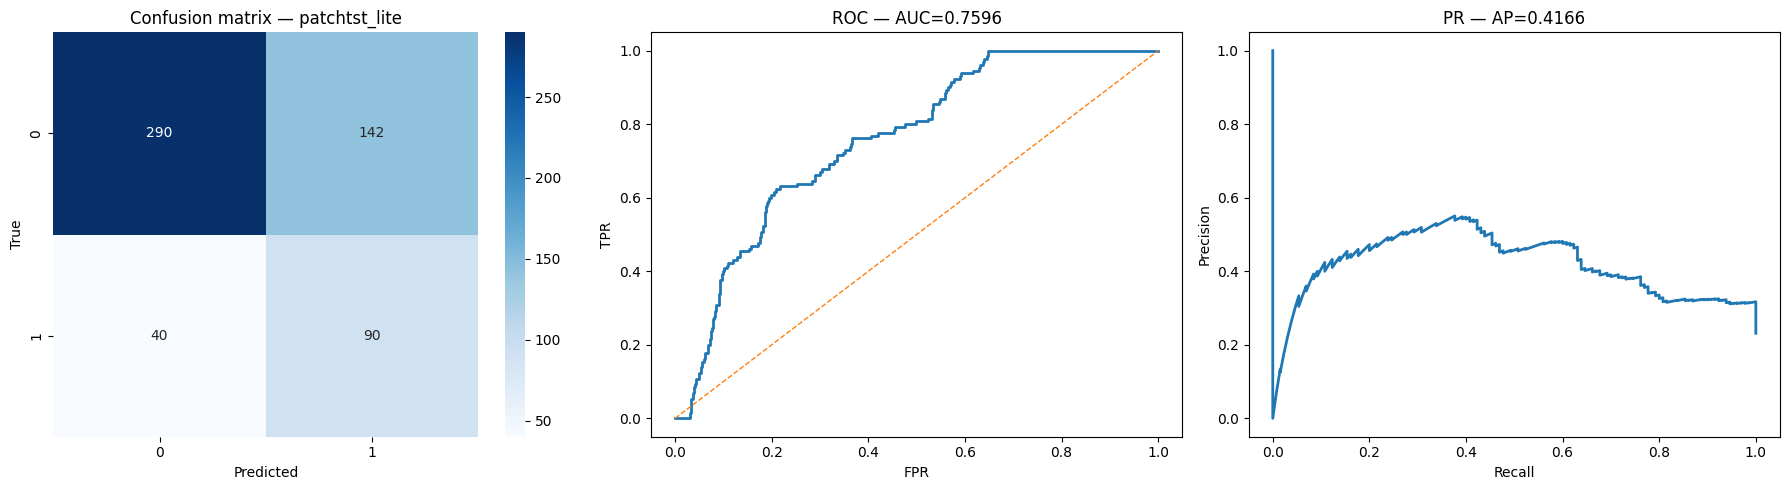

In [19]:
# =========================
# 15) Miglior modello sul test
# =========================

test_results = results_df[results_df["split"] == "test"].sort_values("macro_f1", ascending=False).reset_index(drop=True)
best_name = test_results.loc[0, "model"]
best_art = artifacts[best_name]

print("Best test model:", best_name)
display(test_results.head(10))

best_threshold = best_art["val_threshold"]
best_test_probs = best_art["test_probs"]
best_test_preds = (best_test_probs >= best_threshold).astype(int)

print("\nClassification report:")
print(classification_report(y_test, best_test_preds, digits=4))

cm = confusion_matrix(y_test, best_test_preds)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title(f"Confusion matrix — {best_name}")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

if len(np.unique(y_test)) == 2:
    fpr, tpr, _ = roc_curve(y_test, best_test_probs)
    prec, rec, _ = precision_recall_curve(y_test, best_test_probs)
    axes[1].plot(fpr, tpr, lw=2)
    axes[1].plot([0, 1], [0, 1], "--", lw=1)
    axes[1].set_title(f"ROC — AUC={roc_auc_score(y_test, best_test_probs):.4f}")
    axes[1].set_xlabel("FPR")
    axes[1].set_ylabel("TPR")

    axes[2].plot(rec, prec, lw=2)
    axes[2].set_title(f"PR — AP={average_precision_score(y_test, best_test_probs):.4f}")
    axes[2].set_xlabel("Recall")
    axes[2].set_ylabel("Precision")

plt.tight_layout()
plt.show()

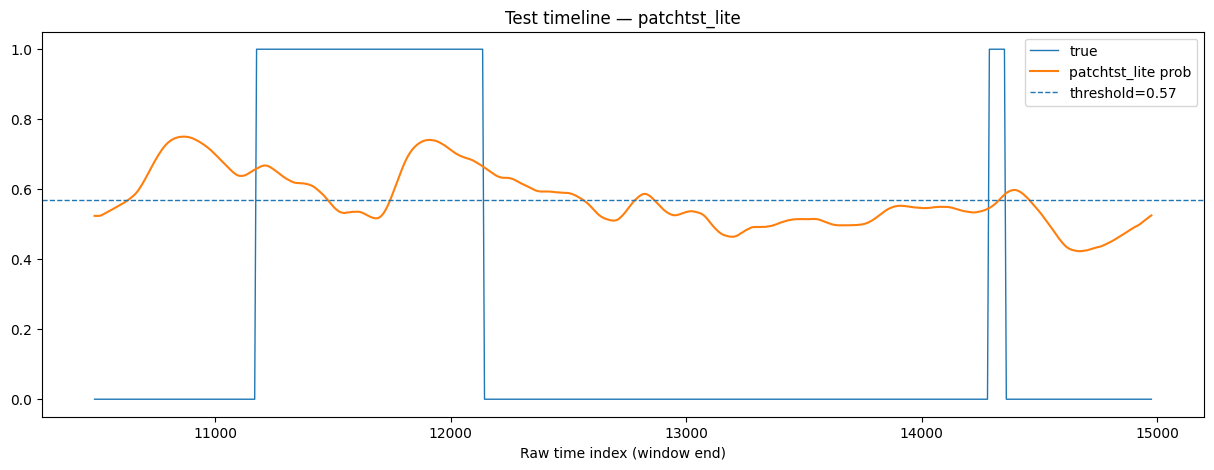

In [20]:
# =========================
# 16) Timeline delle probabilità sul test
# =========================

test_end_idx = end_idx_all[test_mask]

plt.figure(figsize=(15, 5))
plt.plot(test_end_idx, y_test, label="true", lw=1.0)
plt.plot(test_end_idx, best_test_probs, label=f"{best_name} prob", lw=1.5)
plt.axhline(best_threshold, ls="--", lw=1.0, label=f"threshold={best_threshold:.2f}")
plt.title(f"Test timeline — {best_name}")
plt.xlabel("Raw time index (window end)")
plt.legend()
plt.show()

In [21]:
# =========================
# 17) Se il migliore è XGBoost: feature importance
# =========================

if best_name == "xgboost":
    fi = pd.Series(
        artifacts["xgboost"]["final_model"].feature_importances_,
        index=X_tab_pretest.columns
    ).sort_values(ascending=False).head(30)

    plt.figure(figsize=(10, 8))
    fi.sort_values().plot(kind="barh")
    plt.title("Top 30 XGBoost feature importances")
    plt.tight_layout()
    plt.show()
else:
    print("Il miglior modello non è XGBoost; salta questa cella oppure interpretalo con strumenti PyTorch/gradients se ti serve.")

Il miglior modello non è XGBoost; salta questa cella oppure interpretalo con strumenti PyTorch/gradients se ti serve.


## Conclusioni utili per l'esame

Questo notebook è pensato per darti una storia metodologica più forte:

- non stai facendo solo XGBoost
- stai confrontando un baseline tabellare forte con **architetture deep learning moderne**
- stai usando **windowing causale** e non prediction sample-by-sample ingenua
- il test è l'**ultimo 30% temporale untouched**
- il tuning di threshold e smoothing avviene **solo nel passato**

Se vuoi spremere ancora qualcosa:

1. prova `WINDOW_SIZE` in `{64, 128, 256}`
2. prova `LABEL_MODE="last"` oltre a `"majority"`
3. spegni `FAST_MODE` e aumenta le epoche
4. se la macchina regge, fai piccoli sweep su dropout / width dei modelli
5. confronta il best singolo modello con l'ensemble

La parte forte da raccontare è che qui **hai cercato di migliorare davvero le performance senza rompere il rigore temporale**.